In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import math
sys.path.append(os.path.abspath("../Paraproducts"))
from tensor_paraproducts import haar_paraproduct 
import pickle 

# Data load

In [31]:
N = 256
k = 0.61
mxscl = 4
with open(f"Logpot_XP_deg64_vcoef_3_10/{N}_{mxscl}_{k}.pkl", 'rb') as file:
    potdata = pickle.load(file)

rawpotdatahill = potdata['coords'][0][0]
rawpotdatapole = potdata['coords'][0][1]

N = 256
t = 0.005
mxscl = 4
with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", 'rb') as file:
    schrodata = pickle.load(file)

rschrodhone = schrodata['data_schrod'][0][0]
rschrodhtwo = schrodata['data_schrod'][0][1]


mxscl = 5
with open(f"Logpot_XP_deg64_vcoef_3_10/{N}_{mxscl}_{k}.pkl", 'rb') as file:
    potdata_five = pickle.load(file)

with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", 'rb') as file:
    schrodata_five = pickle.load(file)

mxscl = 6
with open(f"Logpot_XP_deg64_vcoef_3_10/{N}_{mxscl}_{k}.pkl", 'rb') as file:
    potdata_six = pickle.load(file)

with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", 'rb') as file:
    schrodata_six = pickle.load(file)

# Figure 1

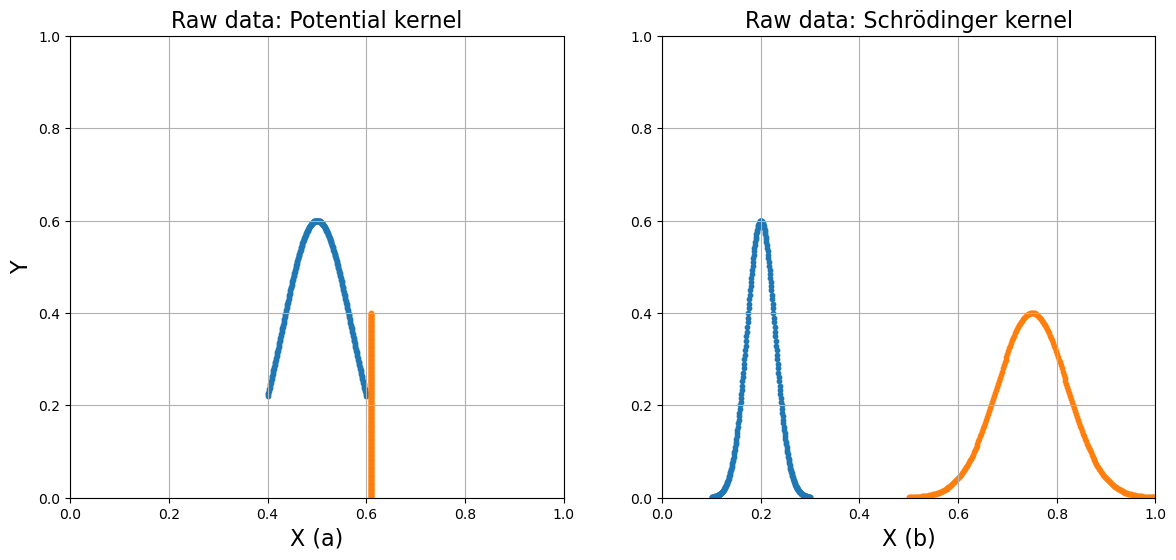

In [32]:
# Create a figure with a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot the sine wave in the first subplot
ax1.scatter(rawpotdatahill[:,0], rawpotdatahill[:,1], s=10,label='Hill')
ax1.scatter(rawpotdatapole[:,0], rawpotdatapole[:,1], s=10,label='Pole')
ax1.set_title("Raw data: Potential kernel",fontsize=16)
ax1.set_xlabel('X (a)',fontsize=16)
ax1.set_ylabel('Y',fontsize=16)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True)

# Plot the sine wave in the first subplot
ax2.scatter(rschrodhone[:,0], rschrodhone[:,1], s=10,label='Hill one')
ax2.scatter(rschrodhtwo[:,0], rschrodhtwo[:,1], s=10,label='Hill two')
ax2.set_title("Raw data: Schr\u00f6dinger kernel",fontsize=16)
ax2.set_xlabel('X (b)',fontsize=16)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(True)

plt.savefig("Figures_pot_schrod/rawdata_pot_schrod.png")

# Figure 2

In [33]:
print(potdata.keys())

dict_keys(['coords', 'dxy', 'Af', 'dxycoeffs', 'Afnorm', 'paranorm', 'logvar'])


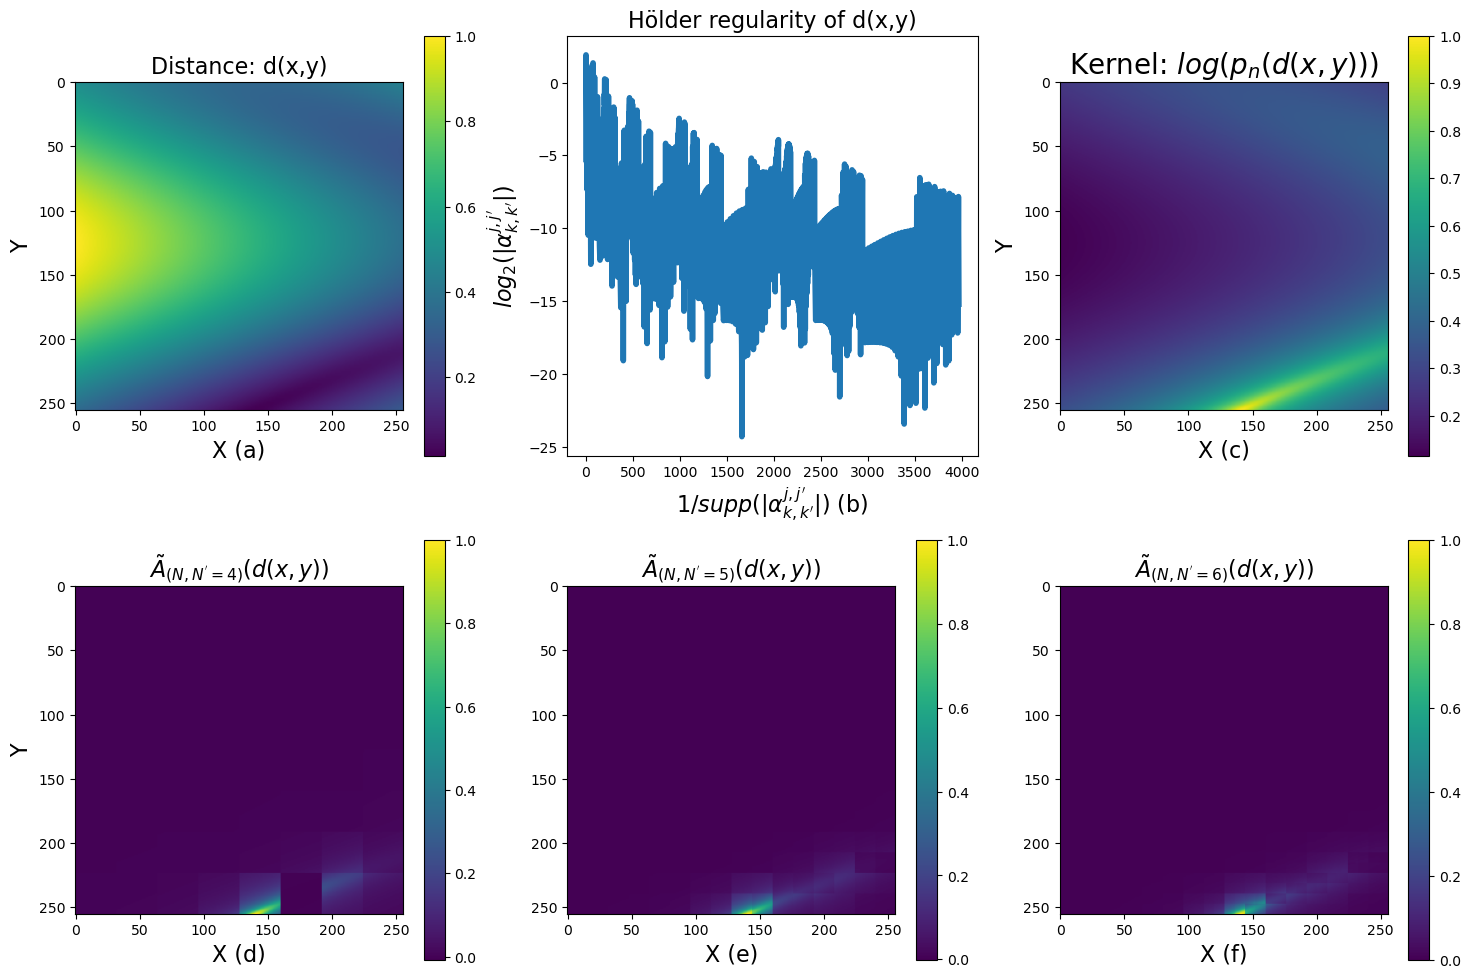

In [34]:
# Extract data
dxypot = potdata['dxy']
Afpot = potdata['Afnorm']
app4pot = potdata['paranorm']
app5pot = potdata_five['paranorm']
app6pot = potdata_six['paranorm']

# Compute normalizations
ndxyschrod = dxypot/np.max(np.abs(dxypot))
nAfpot = Afpot/np.max(np.abs(Afpot))
napp4pot = app4pot/np.max(np.abs(app4pot))
napp5pot = app5pot/np.max(np.abs(app5pot))
napp6pot = app6pot/np.max(np.abs(app6pot))

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
#plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=2.0)

im1 = axes[0, 0].imshow(ndxyschrod)
axes[0, 0].set_title('Distance: d(x,y)',fontsize=16)
axes[0, 0].set_xlabel('X (a)',fontsize=16)
axes[0, 0].set_ylabel('Y',fontsize=16)
fig.colorbar(im1, ax=axes[0,0])

im2 = axes[0, 1].plot(np.log2(potdata['dxycoeffs']),linewidth=4)
axes[0, 1].set_xlabel(r"$1/supp(|\alpha^{j,j'}_{k,k'}|)$ (b)",fontsize=16)
axes[0, 1].set_ylabel(r"$log_2(|\alpha^{j,j'}_{k,k'}|)$",fontsize=16)
axes[0, 1].set_title('H\u00f6lder regularity of d(x,y)',fontsize=16)

im3 = axes[0, 2].imshow(nAfpot)
axes[0, 2].set_title(r"Kernel: $log(p_n(d(x,y)))$",fontsize=20)
axes[0, 2].set_xlabel('X (c)',fontsize=16)
axes[0, 2].set_ylabel('Y',fontsize=16)
fig.colorbar(im3, ax=axes[0,2])

im4 = axes[1, 0].imshow(napp4pot)
axes[1, 0].set_title(r"$\tilde{A}_{(N,N^{'}=4)}(d(x,y))$",fontsize=16)
axes[1, 0].set_xlabel('X (d)',fontsize=16)
axes[1, 0].set_ylabel('Y',fontsize=16)
fig.colorbar(im4, ax=axes[1,0])

im5 = axes[1, 1].imshow(napp5pot)
axes[1, 1].set_title(r"$\tilde{A}_{(N,N^{'}=5)}(d(x,y))$",fontsize=16)
axes[1, 1].set_xlabel('X (e)',fontsize=16)
fig.colorbar(im5, ax=axes[1,1])

im6 = axes[1, 2].imshow(napp6pot)
axes[1, 2].set_title(r"$\tilde{A}_{(N,N^{'}=6)}(d(x,y))$",fontsize=16)
axes[1, 2].set_xlabel('X (f)',fontsize=16)
fig.colorbar(im6, ax=axes[1,2])

plt.savefig("Figures_pot_schrod/pot.png")



# Figure 3: Schrodinger

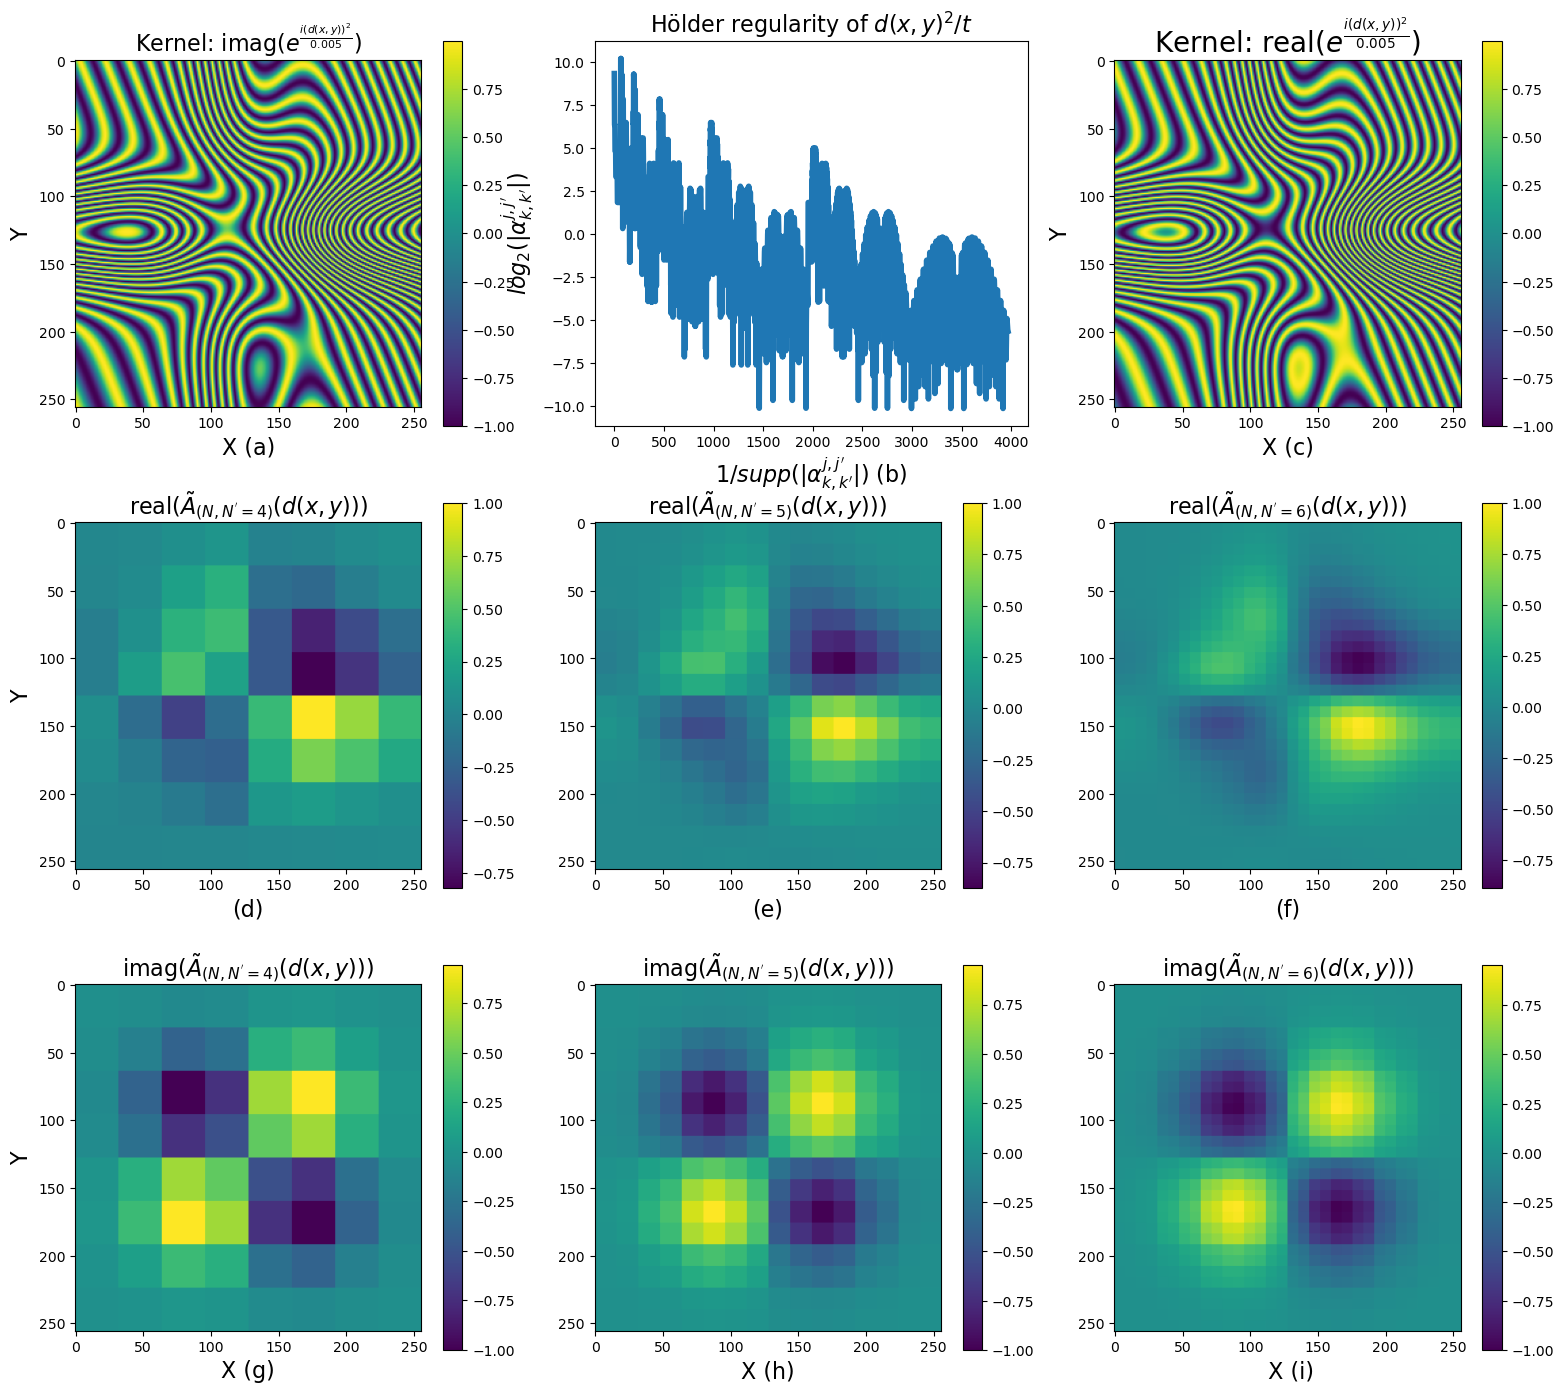

In [20]:
# Extract data
dxyschrod = schrodata['phase']
Afschrodreal = schrodata['Afreal']
sapp4real = schrodata['parareal']
sapp5real = schrodata_five['parareal']
sapp6real = schrodata_six['parareal']
Afschrodimag = schrodata['Afimag']
sapp4imag = schrodata['paraimag']
sapp5imag = schrodata_five['paraimag']
sapp6imag = schrodata_six['paraimag']


# Compute normalizations
ndxyschrod = dxyschrod/np.max(np.abs(dxyschrod))
nAfschrodreal = Afschrodreal/np.max(np.abs(Afschrodreal))
nsapp4real = sapp4real/np.max(np.abs(sapp4real))
nsapp5real = sapp5real/np.max(np.abs(sapp5real))
nsapp6real = sapp6real/np.max(np.abs(sapp6real))
# Compute normalizations
nAfschrodimag = Afschrodimag/np.max(np.abs(Afschrodimag))
nsapp4imag = sapp4imag/np.max(np.abs(sapp4imag))
nsapp5imag = sapp5imag/np.max(np.abs(sapp5imag))
nsapp6imag = sapp6imag/np.max(np.abs(sapp6imag))

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(19, 17))
#plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=2.0)

im1 = axes[0, 0].imshow(nAfschrodimag)
axes[0, 0].set_title(r"Kernel: imag($e^{\frac{i(d(x,y))^2}{0.005}}$)",fontsize=16)
axes[0, 0].set_xlabel('X (a)',fontsize=16)
axes[0, 0].set_ylabel('Y',fontsize=16)
fig.colorbar(im1, ax=axes[0,0])

im2 = axes[0, 1].plot(np.log2(schrodata['phasecoeffs']),linewidth=4)
axes[0, 1].set_xlabel(r"$1/supp(|\alpha^{j,j'}_{k,k'}|)$ (b)",fontsize=16)
axes[0, 1].set_ylabel(r"$log_2(|\alpha^{j,j'}_{k,k'}|)$",fontsize=16)
axes[0, 1].set_title('Hölder regularity of $d(x,y)^2/t$', fontsize=16)

im3 = axes[0, 2].imshow(nAfschrodreal)
axes[0, 2].set_title(r"Kernel: real($e^{\frac{i(d(x,y))^2}{0.005}}$)",fontsize=20)
axes[0, 2].set_xlabel('X (c)',fontsize=16)
axes[0, 2].set_ylabel('Y',fontsize=16)
fig.colorbar(im3, ax=axes[0,2])

im4 = axes[1, 0].imshow(nsapp4real)
axes[1, 0].set_title(r"real($\tilde{A}_{(N,N^{'}=4)}(d(x,y))$)",fontsize=16)
axes[1, 0].set_xlabel('(d)',fontsize=16)
axes[1, 0].set_ylabel('Y',fontsize=16)
fig.colorbar(im4, ax=axes[1,0])

im5 = axes[1, 1].imshow(nsapp5real)
axes[1, 1].set_title(r"real($\tilde{A}_{(N,N^{'}=5)}(d(x,y))$)",fontsize=16)
axes[1, 1].set_xlabel('(e)',fontsize=16)
fig.colorbar(im5, ax=axes[1,1])

im6 = axes[1, 2].imshow(nsapp6real)
axes[1, 2].set_title(r"real($\tilde{A}_{(N,N^{'}=6)}(d(x,y))$)",fontsize=16)
axes[1, 2].set_xlabel('(f)',fontsize=16)
fig.colorbar(im6, ax=axes[1,2])

im7 = axes[2, 0].imshow(nsapp4imag)
axes[2, 0].set_title(r"imag($\tilde{A}_{(N,N^{'}=4)}(d(x,y))$)",fontsize=16)
axes[2, 0].set_xlabel('X (g)',fontsize=16)
axes[2, 0].set_ylabel('Y',fontsize=16)
fig.colorbar(im7, ax=axes[2,0])

im8 = axes[2, 1].imshow(nsapp5imag)
axes[2, 1].set_title(r"imag($\tilde{A}_{(N,N^{'}=5)}(d(x,y))$)",fontsize=16)
axes[2, 1].set_xlabel('X (h)',fontsize=16)
fig.colorbar(im8, ax=axes[2,1])

im9 = axes[2, 2].imshow(nsapp6imag)
axes[2, 2].set_title(r"imag($\tilde{A}_{(N,N^{'}=6)}(d(x,y))$)",fontsize=16)
axes[2, 2].set_xlabel(' X (i)',fontsize=16)
fig.colorbar(im9, ax=axes[2,2])

plt.savefig("Figures_pot_schrod/real_imag_schrod.png")


In [19]:
# Utility function from claude for creating scientific notation

def sci_notation(num):
    mantissa, exp = f"{num:.2e}".split("e")
    return f"{mantissa} x 10^{int(exp)}"
scivec = np.vectorize(sci_notation)


# Table 1: Log Potential

In [22]:
dim = [64,128,256,512]
scales = [4,5,6,7]
condtab = []
for N in dim:
    for mxscl in scales:
        try: 
            with open(f"Logpot_XP_deg64_vcoef_3_10/{N}_{mxscl}_{k}.pkl", 'rb') as file:
                condtab.append(pickle.load(file)['logvar'])
        except: # when scaling parameter is too large
            condtab.append(-1)

condtab = np.array(condtab).reshape(len(dim),len(scales))
fcondtab = scivec(condtab)
print(fcondtab)


[['6.83 x 10^-1' '6.59 x 10^-1' '6.46 x 10^-1' '-1.00 x 10^0']
 ['6.39 x 10^-1' '6.22 x 10^-1' '6.01 x 10^-1' '6.09 x 10^-1']
 ['6.23 x 10^-1' '6.17 x 10^-1' '5.92 x 10^-1' '5.92 x 10^-1']
 ['6.16 x 10^-1' '6.13 x 10^-1' '5.86 x 10^-1' '5.84 x 10^-1']]


# Table 2: Relative Variation, (Real) Schrodinger Kernel (t=0.005)

In [25]:
dim = [64,128,256,512]
scales = [4,5,6,7]
rentrop_real = []
for N in dim:
    for mxscl in scales:
        try: 
            with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", 'rb') as file:
                rentrop_real.append(pickle.load(file)['schrodvar'][0])
        except: # when scaling parameter is too large
            rentrop_real.append(-1)

rentrop_real = np.array(rentrop_real).reshape(len(dim),len(scales))
frentrop_real = scivec(rentrop_real)
print(frentrop_real)


[['1.29 x 10^-3' '3.53 x 10^-3' '2.21 x 10^-2' '-1.00 x 10^0']
 ['1.90 x 10^-3' '4.05 x 10^-3' '1.15 x 10^-2' '7.97 x 10^-2']
 ['2.02 x 10^-3' '4.30 x 10^-3' '9.94 x 10^-3' '2.53 x 10^-2']
 ['2.05 x 10^-3' '4.37 x 10^-3' '1.01 x 10^-2' '2.08 x 10^-2']]


# Table 3: Relative Variation, (Imaginary) Schrodinger Kernel (t=0.005)

In [27]:
dim = [64,128,256,512]
scales = [4,5,6,7]
rentrop_cpx = []
for N in dim:
    for mxscl in scales:
        try: 
            with open(f"Schrodinger_3_11/{N}_{mxscl}_{t}.pkl", 'rb') as file:
                rentrop_cpx.append(pickle.load(file)['schrodvar'][1])
        except: # when scaling parameter is too large
            rentrop_cpx.append(-1)

rentrop_cpx = np.array(rentrop_cpx).reshape(len(dim),len(scales))
rentrop_cpx = scivec(rentrop_cpx)
print(rentrop_cpx)

[['1.61 x 10^-3' '3.46 x 10^-3' '2.45 x 10^-2' '-1.00 x 10^0']
 ['2.39 x 10^-3' '4.97 x 10^-3' '9.51 x 10^-3' '9.22 x 10^-2']
 ['2.57 x 10^-3' '5.33 x 10^-3' '1.02 x 10^-2' '1.83 x 10^-2']
 ['2.62 x 10^-3' '5.42 x 10^-3' '1.03 x 10^-2' '1.86 x 10^-2']]
